# CH 4-24 — Dériver la distribution d’échantillonnage : approche classique

## Objectif pédagogique

Ce cahier illustre comment l’approche classique permet d’estimer l’incertitude autour d’un backtest unique.

L’idée centrale est simple :

- ton backtest donne une **moyenne observée** ;
- cette moyenne n’est pas forcément la vérité ;
- elle est soumise à une **erreur d’échantillonnage** ;
- l’approche classique estime cette erreur avec la formule de l’**erreur standard**.

En trading, cela permet de répondre à une question essentielle :

> Est-ce que la performance moyenne observée dans mon backtest est assez solide, ou peut-elle simplement venir de la chance statistique ?


## 1. Concept clé

On observe une série de rendements de stratégie :

$$r_1, r_2, r_3, ..., r_n$$

La moyenne du backtest est :

$$\bar r = \frac{1}{n}\sum_{i=1}^{n} r_i$$

Mais cette moyenne est seulement une estimation de la vraie moyenne future inconnue.

L’erreur standard mesure l’incertitude autour de cette moyenne :

$$SE = \frac{s}{\sqrt{n}}$$

où :

- $s$ est l’écart-type des rendements observés ;
- $n$ est le nombre d’observations ;
- $SE$ est l’écart-type de la distribution d’échantillonnage de la moyenne.

Plus $n$ augmente, plus $SE$ diminue. Mais attention : il diminue avec $\sqrt{n}$, pas directement avec $n$.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Exemple : une stratégie avec une vraie espérance positive faible
true_mean = 0.0004      # 0.04% par trade
true_std = 0.01         # 1% de volatilité par trade
n_trades = 1000

returns = np.random.normal(loc=true_mean, scale=true_std, size=n_trades)

sample_mean = returns.mean()
sample_std = returns.std(ddof=1)
standard_error = sample_std / np.sqrt(n_trades)

pd.DataFrame({
    "Mesure": ["Moyenne observée", "Écart-type observé", "Nombre de trades", "Erreur standard"],
    "Valeur": [sample_mean, sample_std, n_trades, standard_error]
})


,Mesure,Valeur
0,Moyenne observée,0.000593
1,Écart-type observé,0.009792
2,Nombre de trades,1000.000000
3,Erreur standard,0.000310


## 2. Visualiser la distribution d’échantillonnage théorique

L’approche classique dit que, si le nombre d’observations est suffisant, la moyenne observée suit approximativement une loi normale centrée autour de la vraie moyenne.

Même si les rendements individuels sont bruités, les moyennes deviennent plus stables quand on répète l’expérience.

C’est l’idée du Théorème Central Limite.


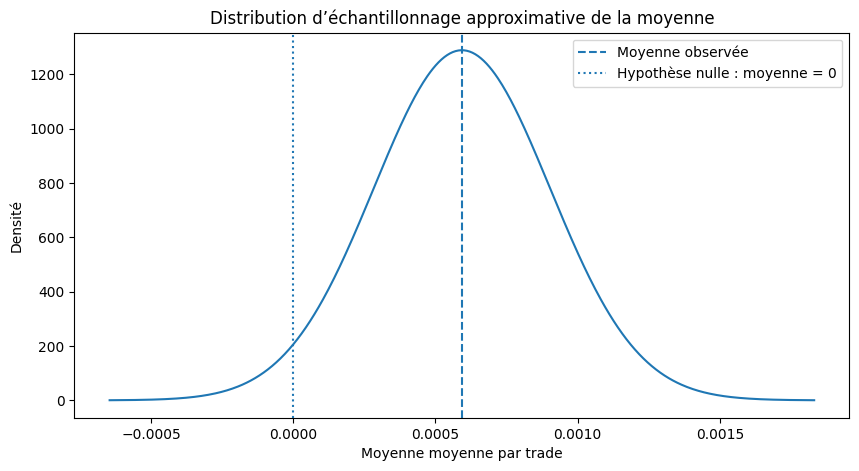

In [2]:
# Distribution théorique des moyennes selon l'approche classique
x = np.linspace(sample_mean - 4 * standard_error, sample_mean + 4 * standard_error, 500)

normal_density = (1 / (standard_error * np.sqrt(2 * np.pi))) * np.exp(
    -0.5 * ((x - sample_mean) / standard_error) ** 2
)

plt.figure(figsize=(10, 5))
plt.plot(x, normal_density)
plt.axvline(sample_mean, linestyle="--", label="Moyenne observée")
plt.axvline(0, linestyle=":", label="Hypothèse nulle : moyenne = 0")
plt.title("Distribution d’échantillonnage approximative de la moyenne")
plt.xlabel("Moyenne moyenne par trade")
plt.ylabel("Densité")
plt.legend()
plt.show()


## 3. Pourquoi la taille d’échantillon est décisive

On va maintenant comparer plusieurs tailles de backtest.

Même stratégie, même volatilité, mais nombre de trades différent.

La formule :

$$SE = \frac{s}{\sqrt{n}}$$

montre qu’un backtest avec plus de trades donne une moyenne plus précise.

Mais le gain est lent : multiplier le nombre de trades par 10 ne divise pas l’erreur par 10, mais par environ 3,16.


In [3]:
sample_sizes = np.array([10, 30, 50, 100, 300, 1000, 3000])
standard_errors = true_std / np.sqrt(sample_sizes)

df_se = pd.DataFrame({
    "Nombre de trades": sample_sizes,
    "Erreur standard estimée": standard_errors
})

df_se


,Nombre de trades,Erreur standard estimée
0,10,0.003162
1,30,0.001826
2,50,0.001414
3,100,0.001000
4,300,0.000577
5,1000,0.000316
6,3000,0.000183


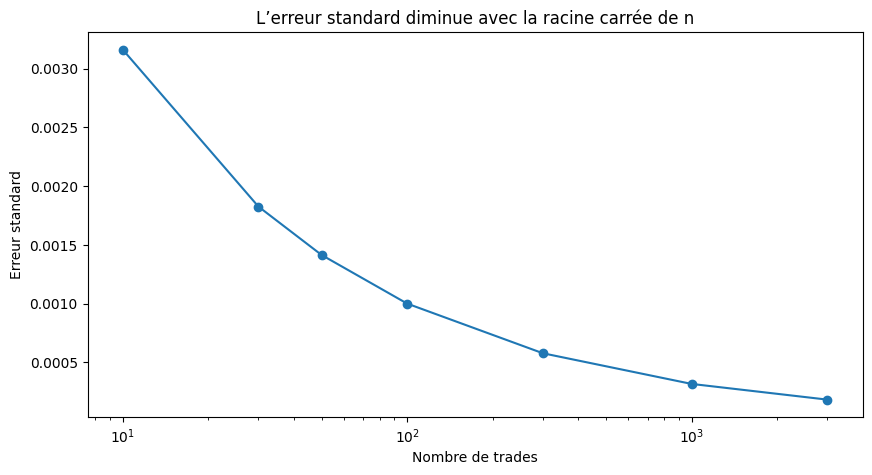

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(sample_sizes, standard_errors, marker="o")
plt.title("L’erreur standard diminue avec la racine carrée de n")
plt.xlabel("Nombre de trades")
plt.ylabel("Erreur standard")
plt.xscale("log")
plt.show()


## 4. Exemple trading : deux backtests avec la même moyenne, mais pas la même fiabilité

Imaginons deux traders qui obtiennent tous les deux une moyenne de +0.05% par trade.

- Trader A : seulement 30 trades.
- Trader B : 1000 trades.

La moyenne est identique, mais la confiance statistique n’est pas la même.


In [5]:
observed_mean = 0.0005
strategy_std = 0.01

cases = pd.DataFrame({
    "Trader": ["A", "B"],
    "Moyenne observée": [observed_mean, observed_mean],
    "Écart-type des trades": [strategy_std, strategy_std],
    "Nombre de trades": [30, 1000]
})

cases["Erreur standard"] = cases["Écart-type des trades"] / np.sqrt(cases["Nombre de trades"])
cases["z-score vs 0"] = cases["Moyenne observée"] / cases["Erreur standard"]

cases


,Trader,Moyenne observée,Écart-type des trades,Nombre de trades,Erreur standard,z-score vs 0
0,A,0.0005,0.01,30,0.001826,0.273861
1,B,0.0005,0.01,1000,0.000316,1.581139


Le z-score ici mesure combien d’erreurs standards séparent la moyenne observée de zéro.

Plus le z-score est élevé, plus il devient difficile d’expliquer la performance par simple hasard.

C’est exactement le pont entre backtest et test d’hypothèse.


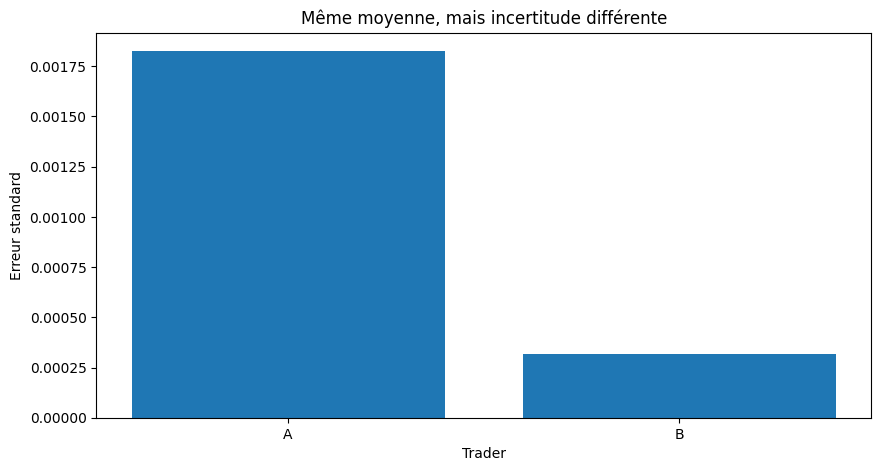

In [6]:
plt.figure(figsize=(10, 5))
plt.bar(cases["Trader"], cases["Erreur standard"])
plt.title("Même moyenne, mais incertitude différente")
plt.xlabel("Trader")
plt.ylabel("Erreur standard")
plt.show()


## 5. Simulation pour vérifier l’intuition

L’approche classique donne une formule.

Mais on peut aussi simuler plusieurs backtests pour observer la distribution des moyennes.

Cela permet de voir concrètement que les moyennes de petits échantillons sont très dispersées, alors que les moyennes de grands échantillons sont beaucoup plus concentrées.


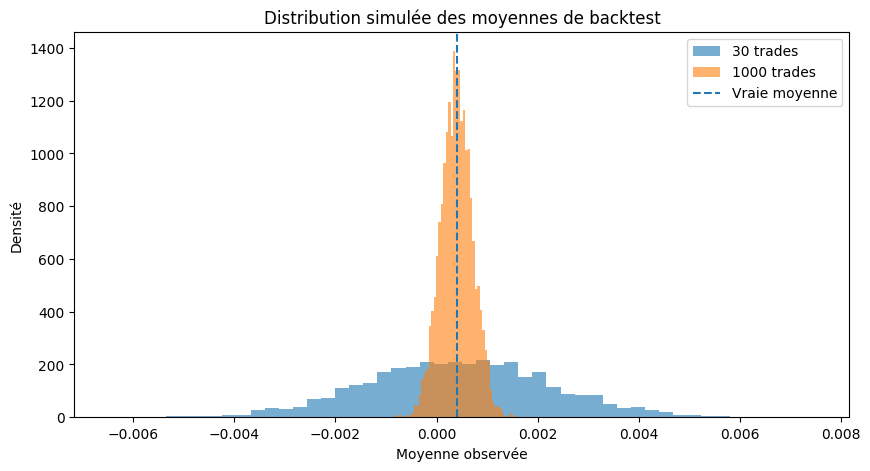

In [7]:
def simulate_backtest_means(n_trades, n_simulations=5000, mean=true_mean, std=true_std):
    simulations = np.random.normal(loc=mean, scale=std, size=(n_simulations, n_trades))
    return simulations.mean(axis=1)

means_30 = simulate_backtest_means(30)
means_1000 = simulate_backtest_means(1000)

plt.figure(figsize=(10, 5))
plt.hist(means_30, bins=50, alpha=0.6, density=True, label="30 trades")
plt.hist(means_1000, bins=50, alpha=0.6, density=True, label="1000 trades")
plt.axvline(true_mean, linestyle="--", label="Vraie moyenne")
plt.title("Distribution simulée des moyennes de backtest")
plt.xlabel("Moyenne observée")
plt.ylabel("Densité")
plt.legend()
plt.show()


## 6. Lecture pratique pour un trader

La leçon n’est pas : “un grand backtest garantit un edge”.

La vraie leçon est :

> Plus le nombre de trades est faible et plus la volatilité des résultats est forte, plus tu dois douter de la moyenne observée.

Donc, quand tu regardes un backtest, ne regarde pas seulement :

- le PnL ;
- le winrate ;
- la moyenne par trade ;
- la courbe d’équité.

Regarde aussi :

- le nombre de trades ;
- l’écart-type des trades ;
- l’erreur standard ;
- la distance entre la moyenne observée et zéro.


In [8]:
def backtest_statistical_summary(returns):
    returns = np.asarray(returns)
    n = len(returns)
    mean = returns.mean()
    std = returns.std(ddof=1)
    se = std / np.sqrt(n)
    z = mean / se if se != 0 else np.nan
    return pd.Series({
        "Nombre de trades": n,
        "Moyenne par trade": mean,
        "Écart-type des trades": std,
        "Erreur standard": se,
        "z-score vs zéro": z
    })

summary = backtest_statistical_summary(returns)
summary


Nombre de trades         1000.000000
Moyenne par trade           0.000593
Écart-type des trades       0.009792
Erreur standard             0.000310
z-score vs zéro             1.916068
dtype: float64

## 7. Interprétation EBTA

Dans une logique EBTA, tu ne dois pas traiter la moyenne du backtest comme une vérité.

Tu dois la traiter comme une mesure bruitée.

Un backtest devient plus crédible quand :

- la moyenne est positive ;
- l’erreur standard est faible ;
- le nombre d’observations est suffisant ;
- la volatilité des rendements ne rend pas la moyenne trop incertaine ;
- la performance reste cohérente hors-échantillon.

La formule de l’erreur standard est donc une arme anti-illusion.

Elle force le trader à se demander :

> Mon résultat est-il grand par rapport au bruit ?


## À retenir absolument

1. Une moyenne de backtest n’est pas la vérité, c’est une estimation.
2. L’erreur standard mesure le doute autour de cette estimation.
3. Plus le nombre de trades augmente, plus l’estimation devient précise.
4. Plus les rendements sont volatils, plus le doute augmente.
5. Une stratégie rentable mais très bruitée peut être statistiquement fragile.
6. Avant de croire une moyenne positive, demande-toi toujours si elle est suffisamment grande par rapport à son erreur standard.
